# Setting up a basic ReAct Agent in LangGraph

In [16]:
# Option 1: Specify the .env path explicitly (faster)
from dotenv import load_dotenv
import os

env_path = os.path.join(os.path.dirname(os.getcwd()), '.env')
load_dotenv(env_path)
print("Loaded environment variables from .env file")

# Display variable names loaded (not values for security)
if os.path.exists(env_path):
    with open(env_path, 'r') as f:
        vars_loaded = [line.split('=')[0].strip() for line in f if '=' in line and not line.strip().startswith('#')]
    print(f"\nVariables found in .env: {', '.join(vars_loaded)}")

Loaded environment variables from .env file

Variables found in .env: OPENAI_API_KEY, ANTHROPIC_API_KEY, GEMINI_API_KEY, GROQ_API_KEY, DEEPSEEK_API_KEY, OPENROUTER_API_KEY, SERPAPI_API_KEY, SERP_API_KEY, FIRECRAWL_API_KEY, HF_TOKEN, GOOGLE_CREDENTIALS, MOONSHOT_API_KEY


In [17]:
# Load tools for the ReAct agent
# load_tools is a utility function that loads and initializes LangChain tools
# The "serpapi" tool enables the agent to perform web searches via SerpAPI
# This is essential for the ReAct agent to gather real-time information from the web
from langchain_community.agent_toolkits.load_tools import load_tools
tools = load_tools(["serpapi"])
tools[0].run("What is the capital of France?")  # Test the SerpAPI tool to ensure it's working

'["As the capital of France, Paris is the seat of France\'s national government ; Both houses of the French Parliament ; France\'s highest courts are located in Paris.", "What is the capital of FRANCE? 110K. 4,477. Share. Video unavailable. This content isn\'t available. Skip video.", \'Paris is the city of romance par excellence, the fashion capital and the best example of French art de vivre. Exploring Paris is an essential rite of passage ...\', \'Paris is the capital and most populous city of France. Situated on the Seine River, in the north of the country, it is in the centre of the Île-de-France ...\', \'Paris is the capital of France, the largest country of Europe with 550 000 km2 (65 millions inhabitants). Paris has 2.234 million inhabitants end 2011.\', \'Paris, the capital of France, is famed for its elegant architecture, world-class museums, romantic atmosphere, and iconic landmarks.\', \'France, country of northwestern Europe. Historically and culturally among the most impo

In [5]:
# Display the loaded tools to verify what tools are available for the ReAct agent
# This will show the tool name, description, and function details
print(tools[0].name)
print(tools[0].description)

Search
A search engine. Useful for when you need to answer questions about current events. Input should be a search query.


In [18]:
tools[0].run('Sinan Ozdemir')

'[\'Ozdemir Sinan : Sinan is an active lecturer focusing on large language models and a former lecturer of data science at the Johns Hopkins University. He is the author of multiple textbooks on data science and machine learning including "Quick Start Guide to LLMs". ...\', \'Sinan Ozdemir type: Author.\', \'Sinan Ozdemir entity_type: people.\', \'Sinan Ozdemir kgmid: /g/11hcjs9cr6.\', "I\'ve spent 12+ years at the intersection of AI research, education, and building: from founding Kylie.ai (YC, acquired) and patenting tool-use agents in 2018, ...", \'Helping companies leverage AI technology to solve complex problems. Founder, author, and consultant specializing in AI, LLMs, and data science.\', \'Data Scientist + Author + Entrepreneur. Check out my new book on LLMs on Amazon (Top 10 in AI/NLP) - sinanuozdemir.\', "A beginner\'s guide to essential math and coding skills for data fluency and machine learning by Sinan Ozdemir", \'Sinan Ozdemir (@Prof_OZ) - Posts - AI Education @Fireworks

In [24]:
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
from datetime import datetime

today = datetime.today().strftime("%B ") + str(datetime.today().day) + ("th" if 11<=datetime.today().day<=13 else {1:"st",2:"nd",3:"rd"}.get(datetime.today().day%10,"th")) + datetime.today().strftime(", %Y")
print(today)

# Use Kimi (Moonshot AI) instead of OpenAI
moonshot_key = os.getenv("MOONSHOT_API_KEY")
if not moonshot_key:
    raise ValueError("MOONSHOT_API_KEY not found in environment. Please add it to your .env file.")

llm = ChatOpenAI(
    model="kimi-k2.6",
    base_url="https://api.moonshot.ai/v1",
    api_key=moonshot_key
)
agent_executor = create_react_agent(
    llm, tools, prompt=f'Today is {today}')

June 30th, 2026


/var/folders/1g/lz4110yd5_x6_lhf4pqkrphr0000gn/T/ipykernel_18229/2852279088.py:18: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(


In [23]:
# Test Moonshot API connection directly
import os
from openai import OpenAI

moonshot_key = os.getenv("MOONSHOT_API_KEY")
print(f"Key loaded: {'Yes' if moonshot_key else 'No'}")
print(f"Key starts with: {moonshot_key[:10]}..." if moonshot_key else "No key")

# Test direct API call
client = OpenAI(
    api_key=moonshot_key,
    base_url="https://api.moonshot.ai/v1"
)

try:
    response = client.chat.completions.create(
        model="kimi-k2.5",
        messages=[{"role": "user", "content": "Hello, are you working?"}],
        max_tokens=50
    )
    print(f"\nAPI Test Success!")
    print(f"Response: {response.choices[0].message.content}")
except Exception as e:
    print(f"\nAPI Test Failed: {e}")

Key loaded: Yes
Key starts with: sk-TuQTfwj...

API Test Success!
Response: 


In [25]:
response = agent_executor.invoke(
    {"messages": [("user", "Who is the current Ravens QB?")]})

In [26]:
response['messages'][-1].content

"The current starting quarterback for the Baltimore Ravens is **Lamar Jackson**.\n\nHe has been the Ravens' starting QB since 2018 and remains their QB heading into the 2026 season. According to the depth chart, his backups include Tyler Huntley, Joe Fagnano, and Diego Pavia, with the team also recently adding Skylar Thompson for competition."

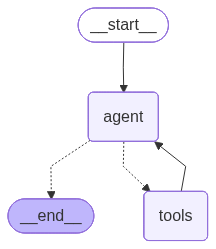

In [27]:
# Compile the graph
from IPython.display import Image, display

display(Image(agent_executor.get_graph().draw_mermaid_png()))

In [28]:
response = agent_executor.invoke({"messages": [("user", "Who is the current Ravens QB?")]})

print(response['messages'][-1].content)

The current starting quarterback for the Baltimore Ravens is **Lamar Jackson**. He remains the team's QB1 as of the 2026 season, with Tyler Huntley listed as the backup quarterback on the depth chart.


In [11]:
response

{'messages': [HumanMessage(content='Who is the current Ravens QB?', additional_kwargs={}, response_metadata={}, id='0522fbb1-9315-4363-a2bc-22bae2ce2309'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 168, 'total_tokens': 193, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DcY1WDDlHveM9qq7PtptzNFBejyEF', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dfdcd-e4d8-72b3-94cf-bc3c68c16545-0', tool_calls=[{'name': 'Search', 'args': {'__arg1': 'current Baltimore Ravens quarterback 2026 season'}, 'id': 'call_a5yHIDnN5sFM8gwpXoZ26cXQ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metad

In [29]:
for message in response['messages']:
    print(f"\n{message.__class__.__name__}:")
    if hasattr(message, 'content') and message.content:
        print(f"  Content: {message.content}")
    if hasattr(message, 'tool_calls') and message.tool_calls:
        print(f"  Tool Calls: {message.tool_calls}")


HumanMessage:
  Content: Who is the current Ravens QB?

AIMessage:
  Tool Calls: [{'name': 'Search', 'args': {'__arg1': 'current Baltimore Ravens starting quarterback 2026'}, 'id': 'Search_0', 'type': 'tool_call'}]

ToolMessage:
  Content: ['Baltimore Ravens Depth Chart ; Lamar Jackson · Tyler Huntley · Joe Fagnano · Diego Pavia ; Derrick Henry · Justice Hill · Rasheen Ali · Adam Randall.', 'Active ; Lamar Jackson. 8, QB ; John Jenkins. 94, DL ; Cornelius Johnson. 86, WR ; Carl Jones Jr. 48, LB ...', "Ravens' Projected Depth Chart After the Draft ; Quarterback · Lamar Jackson · Tyler Huntley ; Running Back · Derrick Henry · Justice Hill ; Tight End.", 'Twenty-five quarterbacks have started at least one game for the Baltimore Ravens of the National Football League (NFL). Seven of those quarterbacks have ...', 'Roster ; Dominic DeLuca. 42, LB ; Ryan Eckley. 30, P ; Luke Elzinga. 31, P ; Joe Fagnano. 12, QB ...', 'Ravens 2026 Positional Assessment: Quarterbacks · Key Contracts. Starter: 

# Giving Our Agent Short Term Memory

In [30]:
from langgraph.graph import MessagesState, END, StateGraph, START
from langchain_core.messages import HumanMessage, AIMessage


In [31]:
agent_executor.invoke({"messages": [("user", "Hi I am Sinan")]})['messages'][-1].content

"Hi Sinan! It's nice to meet you. I'm Kimi, an AI assistant. How can I help you today?"

In [32]:
agent_executor.invoke({"messages": [("user", "What is my name?")]})['messages'][-1].content

"I don't know your name. I don't have access to your personal information, identity, or any previous conversation history.\n\nIf you'd like, you can tell me your name or what you'd prefer I call you!"

In [33]:
from langgraph.checkpoint.memory import MemorySaver  # built in short term memory

In [37]:
# Use Kimi (Moonshot AI) instead of OpenAI
moonshot_key = os.getenv("MOONSHOT_API_KEY")
if not moonshot_key:
    raise ValueError("MOONSHOT_API_KEY not found in environment. Please add it to your .env file.")

llm = ChatOpenAI(
    model="kimi-k2.6",
    base_url="https://api.moonshot.ai/v1",
    api_key=moonshot_key
)

short_term_memory_agent_executor = create_react_agent(
    llm, tools, prompt=f'Today is {today}', checkpointer=MemorySaver()
)

/var/folders/1g/lz4110yd5_x6_lhf4pqkrphr0000gn/T/ipykernel_18229/3566680060.py:12: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  short_term_memory_agent_executor = create_react_agent(


In [38]:
short_term_memory_agent_executor.invoke(
    {"messages": [HumanMessage(content="Hi I am Sinan")]},
    config={"configurable": {"thread_id": "thread_1"}}
)['messages'][-1].content

"Hello Sinan! It's nice to meet you. I'm Claude, an AI assistant. How can I help you today?"

In [39]:
short_term_memory_agent_executor.invoke(
    {"messages": [HumanMessage(content="What is my name?")]},
    config={"configurable": {"thread_id": "thread_1"}}
)['messages'][-1].content

'Your name is Sinan. You told me that in your first message.'

In [40]:
short_term_memory_agent_executor.invoke(
    {"messages": [HumanMessage(content="What is my name?")]},
    config={"configurable": {"thread_id": "thread_2"}}
)['messages'][-1].content

"I don't know your name. I don't have access to personal information about you unless you share it with me during our conversation.\n\nIf you'd like, you can tell me your name and I'll use it in our chat!"